In [1]:
import numpy as np
import torch

ModuleNotFoundError: No module named 'torch'

In [2]:
!pip install torch torchvision torchaudio

   ---------------------------------------- 0.0/114.6 MB ? eta -:--:--
   ---------------------------------------- 0.3/114.6 MB ? eta -:--:--
   ---------------------------------------- 0.5/114.6 MB 1.3 MB/s eta 0:01:31
   ---------------------------------------- 0.8/114.6 MB 1.1 MB/s eta 0:01:40
   ---------------------------------------- 1.0/114.6 MB 1.2 MB/s eta 0:01:34
    --------------------------------------- 1.6/114.6 MB 1.6 MB/s eta 0:01:13
    --------------------------------------- 2.4/114.6 MB 1.9 MB/s eta 0:00:59
    --------------------------------------- 2.6/114.6 MB 2.0 MB/s eta 0:00:58
   - -------------------------------------- 3.4/114.6 MB 2.1 MB/s eta 0:00:54
   - -------------------------------------- 3.9/114.6 MB 2.1 MB/s eta 0:00:52
   - -------------------------------------- 4.5/114.6 MB 2.2 MB/s eta 0:00:51
   - -------------------------------------- 5.0/114.6 MB 2.2 MB/s eta 0:00:50
   - -------------------------------------- 5.5/114.6 MB 2.2 MB/s eta 0:00:49


  Consider adding this directory to PATH or, if you prefer to suppress this warning, use --no-warn-script-location.
  Consider adding this directory to PATH or, if you prefer to suppress this warning, use --no-warn-script-location.


In [3]:
import torch

In [4]:
#Making trained data
#Input variables (temp, rainfall, humidity) ---> using this predict yield of apple and crops

inputs = np.array([
    [73, 67,43],
    [91, 88, 64],
    [87, 134, 58],
    [102, 43, 37],
    [69, 96, 70]
] , dtype = 'float32')

In [5]:
target = np.array([
    [56,70],
    [81, 101],
    [119, 113],
    [22,37],
    [103,119]
], dtype='float32')

In [6]:
inputs = torch.from_numpy(inputs)
target = torch.from_numpy(target)
print(inputs)
print(target)

tensor([[ 73.,  67.,  43.],
        [ 91.,  88.,  64.],
        [ 87., 134.,  58.],
        [102.,  43.,  37.],
        [ 69.,  96.,  70.]])
tensor([[ 56.,  70.],
        [ 81., 101.],
        [119., 113.],
        [ 22.,  37.],
        [103., 119.]])


In [7]:
#Weights and biases
w = torch.randn(2,3, requires_grad = True)
b = torch.randn(2, requires_grad=True)
print(w)
print(b)

tensor([[ 1.0472,  1.1646,  0.2926],
        [-0.4808, -0.6172, -1.2417]], requires_grad=True)
tensor([0.3988, 0.6158], requires_grad=True)


In [8]:
def model(x):
    return x @ w.t()+b

In [9]:
w.t().shape

torch.Size([3, 2])

In [10]:
#prediction 
preds = model(inputs)
print(preds)

tensor([[ 167.4548, -129.2288],
        [ 216.9060, -176.9203],
        [ 264.5353, -195.9374],
        [ 168.1156, -120.9099],
        [ 204.9411, -178.7300]], grad_fn=<AddBackward0>)


In [11]:
#loss function we will use is MSE --> Mean squared error

#MSE = sumation(Ypred - Ytrue)^2 / n
def MSE(y, y_hat):
    diff = y - y_hat

    return torch.sum(diff*diff)/diff.numel()

In [12]:
#error
loss = MSE(target, preds)
print(loss)

tensor(40976.7695, grad_fn=<DivBackward0>)


In [13]:
#compute Gradients
loss.backward()

In [14]:
print(b)

tensor([0.3988, 0.6158], requires_grad=True)


In [15]:
print(b.grad)

tensor([ 128.1906, -248.3453])


In [16]:
w.grad.zero_()
b.grad.zero_()
print(b.grad)

tensor([0., 0.])


In [17]:
preds = model(inputs)
print(preds)
loss = MSE(target, preds)

tensor([[ 167.4548, -129.2288],
        [ 216.9060, -176.9203],
        [ 264.5353, -195.9374],
        [ 168.1156, -120.9099],
        [ 204.9411, -178.7300]], grad_fn=<AddBackward0>)


In [18]:
loss.backward()

In [19]:
learning_rate = 1e-5
with torch.no_grad():
    w -= w.grad * learning_rate
    b -= b.grad * learning_rate

w.grad.zero_()
b.grad.zero_()

tensor([0., 0.])

In [20]:
preds = model(inputs)
loss = MSE(target, preds)
print(loss)

tensor(27830.2090, grad_fn=<DivBackward0>)


In [21]:
for i in range(400):
    preds = model(inputs)
    loss = MSE(target, preds)
    loss.backward()
    with torch.no_grad():
        w -= w.grad * learning_rate
        b -= b.grad * learning_rate

        w.grad.zero_()
        b.grad.zero_()
    print(f"Epochs {i}/{100} & Loss {loss}")

Epochs 0/100 & Loss 27830.208984375
Epochs 1/100 & Loss 18968.970703125
Epochs 2/100 & Loss 12995.5615234375
Epochs 3/100 & Loss 8968.2529296875
Epochs 4/100 & Loss 6252.41064453125
Epochs 5/100 & Loss 4420.36865234375
Epochs 6/100 & Loss 3183.931640625
Epochs 7/100 & Loss 2348.8857421875
Epochs 8/100 & Loss 1784.352294921875
Epochs 9/100 & Loss 1402.13525390625
Epochs 10/100 & Loss 1142.800048828125
Epochs 11/100 & Loss 966.2937622070312
Epochs 12/100 & Loss 845.62548828125
Epochs 13/100 & Loss 762.6057739257812
Epochs 14/100 & Loss 704.9769897460938
Epochs 15/100 & Loss 664.4788818359375
Epochs 16/100 & Loss 635.5443115234375
Epochs 17/100 & Loss 614.421630859375
Epochs 18/100 & Loss 598.58251953125
Epochs 19/100 & Loss 586.3228759765625
Epochs 20/100 & Loss 576.4937133789062
Epochs 21/100 & Loss 568.321044921875
Epochs 22/100 & Loss 561.2828979492188
Epochs 23/100 & Loss 555.0271606445312
Epochs 24/100 & Loss 549.31640625
Epochs 25/100 & Loss 543.9905395507812
Epochs 26/100 & Loss 5

In [22]:
preds = model(inputs)
loss = MSE(target, preds)
print(loss)

tensor(107.7982, grad_fn=<DivBackward0>)


In [23]:
from math import sqrt
sqrt(loss)

C:\Users\Aryan\AppData\Local\Temp\ipykernel_16940\3167310485.py:2: UserWarning: Converting a tensor with requires_grad=True to a scalar may lead to unexpected behavior.
Consider using tensor.detach() first. (Triggered internally at C:\actions-runner\_work\pytorch\pytorch\pytorch\torch\csrc\autograd\generated\python_variable_methods.cpp:837.)
  sqrt(loss)


10.38258985018046

In [24]:
preds

tensor([[ 58.2332,  68.8275],
        [ 78.9181,  91.4043],
        [124.4569, 131.6660],
        [ 26.5084,  46.6052],
        [ 93.1086,  99.3383]], grad_fn=<AddBackward0>)

In [25]:
target

tensor([[ 56.,  70.],
        [ 81., 101.],
        [119., 113.],
        [ 22.,  37.],
        [103., 119.]])

In [26]:
import torch
from torch import nn
from torch.utils.data import DataLoader
from torchvision import datasets
from torchvision.transforms import ToTensor, Lambda, Compose
import matplotlib.pyplot as plt

In [27]:
#Download training data from open datasets

training_data = datasets.FashionMNIST(
    root = 'data',
    train = True,
    download = True,
    transform = ToTensor()
)

#Download test data from open dataset

test_data = datasets.FashionMNIST(
    root="data",
    train=False,
    download=True,
    transform=ToTensor()
)

100%|██████████| 26.4M/26.4M [00:23<00:00, 1.14MB/s]
100%|██████████| 29.5k/29.5k [00:00<00:00, 167kB/s]
100%|██████████| 4.42M/4.42M [00:03<00:00, 1.44MB/s]
100%|██████████| 5.15k/5.15k [00:00<00:00, 7.88MB/s]


In [28]:
type(training_data)

torchvision.datasets.mnist.FashionMNIST

In [29]:
batch_size= 64

#Create data loader
train_dataloader = DataLoader(training_data, batch_size = batch_size)
test_dataloader = DataLoader(test_data, batch_size=batch_size)

for X,y in test_dataloader:
    print("Shape of X [N,C,H,W]", X.shape)
    print("Shape of y:", y.shape, y.dtype)
    break

Shape of X [N,C,H,W] torch.Size([64, 1, 28, 28])
Shape of y: torch.Size([64]) torch.int64


In [30]:
device = "cuda" if torch.cuda.is_available() else "cpu"
print(f"using {device}")

using cpu


In [31]:
#Define the NN model
class NeuralNetwork(nn.Module):

    def __init__(self):
        super(NeuralNetwork, self).__init__()
        self.flatten = nn.Flatten()

        #Hidden layer with Relu
        self.linear_relu_stack = nn.Sequential(
            nn.Linear(28*28, 512),
            nn.ReLU(),
            nn.Linear(512, 512),
            nn.ReLU(),
            nn.Linear(512,10)
        )

    def forward(self, x):
        x = self.flatten(x)
        logits = self.linear_relu_stack(x)
        return logits
    
model = NeuralNetwork().to(device)
print(model)
        

NeuralNetwork(
  (flatten): Flatten(start_dim=1, end_dim=-1)
  (linear_relu_stack): Sequential(
    (0): Linear(in_features=784, out_features=512, bias=True)
    (1): ReLU()
    (2): Linear(in_features=512, out_features=512, bias=True)
    (3): ReLU()
    (4): Linear(in_features=512, out_features=10, bias=True)
  )
)


In [32]:
#Cross Entropy loss ---> Because it is a multiclass classification problem
loss_fn = nn.CrossEntropyLoss()

#Optimizer ----> SGD ----> stochastic gradient descent

optimizer = torch.optim.SGD(model.parameters(), lr = 1e-3)

In [33]:
#Model training
def train(dataloader, model, loss_fn, optimizer):
    size = len(dataloader.dataset)
    model.train()

    for batch, (X,y) in enumerate(dataloader):
        X,y = X.to(device), y.to(device)

        #Compute prediction error
        pred = model(X)
        loss = loss_fn(pred, y)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        if batch %100 ==0:
            loss, current = loss.item(), batch * len(X)
            print(f"Loss: {loss} [{current}/{size}]")

In [34]:
def test(dataloader, model, loss_fn):
    size = len(dataloader.dataset)
    num_batches = len(dataloader)
    model.eval()
    test_loss, correct = 0,0
    with torch.no_grad():
        for X,y in dataloader:
            X,y = X.to(device), y.to(device)
            pred = model(X)

            test_loss += loss_fn(pred, y).item()
            correct += (pred.argmax(1) == y).type(torch.float).sum().item()
    test_loss /= num_batches
    correct /= size
    print(f"Test Error: \n Accuracy: {100*correct} %, Avg loss =  {test_loss}")

In [35]:
epoch = 5
for t in range(epoch):
    print(f"Epoch {t+1}\n -------")
    train(train_dataloader, model, loss_fn, optimizer)
    test(test_dataloader, model, loss_fn)

print("Done \n")

Epoch 1
 -------
Loss: 2.307419538497925 [0/60000]
Loss: 2.2913646697998047 [6400/60000]
Loss: 2.270223617553711 [12800/60000]
Loss: 2.266547441482544 [19200/60000]
Loss: 2.2581918239593506 [25600/60000]
Loss: 2.229727029800415 [32000/60000]
Loss: 2.2368123531341553 [38400/60000]
Loss: 2.204630136489868 [44800/60000]
Loss: 2.205331563949585 [51200/60000]
Loss: 2.175246000289917 [57600/60000]
Test Error: 
 Accuracy: 44.31 %, Avg loss =  2.164188875514231
Epoch 2
 -------
Loss: 2.173938751220703 [0/60000]
Loss: 2.1583199501037598 [6400/60000]
Loss: 2.1026370525360107 [12800/60000]
Loss: 2.1229376792907715 [19200/60000]
Loss: 2.0801806449890137 [25600/60000]
Loss: 2.023343324661255 [32000/60000]
Loss: 2.0469534397125244 [38400/60000]
Loss: 1.972183346748352 [44800/60000]
Loss: 1.9796781539916992 [51200/60000]
Loss: 1.9064711332321167 [57600/60000]
Test Error: 
 Accuracy: 58.4 %, Avg loss =  1.9042358686969538
Epoch 3
 -------
Loss: 1.9310845136642456 [0/60000]
Loss: 1.8960914611816406 [64

In [36]:
#save model
torch.save(model.state_dict(), "model.pth")
print("saved model state tomodel.pth")

saved model state tomodel.pth


In [37]:
classes = [
    "t-shirt/top",
    "Trouser",
    "Pullover",
    "Dress",
    "Coat",
    "Sandal",
    "Shirt",
    "Sneaker",
    "Bag",
    "Ankle boot",
]
model.eval()
x,y = test_data[1][0], test_data[1][1]
x = x.to(device)
with torch.no_grad():
    pred = model(x)
    predicted, actual = classes[pred[0].argmax(0)], classes[y]
    print(f"Predicted: {predicted} Actual: {actual}")

Predicted: Pullover Actual: Pullover


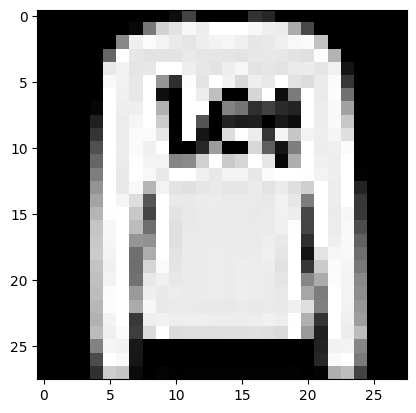

In [38]:
import matplotlib.pyplot as plt

plt.imshow(x.cpu().squeeze(), cmap="gray")
plt.show()